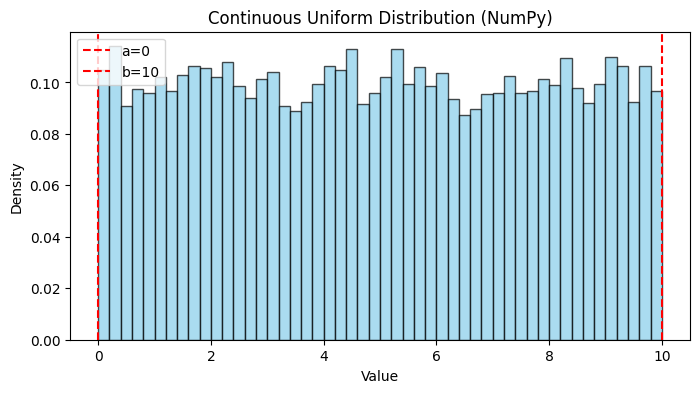

In [ ]:
import numpy as np
import matplotlib.pyplot as plt 
a,b = 0,10
sample_size = 10000
data_continuous = np.random.uniform(low = a,high = b,size = sample_size)
plt.figure(figsize=(8,4))
plt.hist(data_continuous,bins=50,density=True,alpha=0.7,color='skyblue',edgecolor='black')
plt.title('Continuous Uniform Distribution (NumPy)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.axvline(a,color='r',linestyle='--',label=f'a={a}')
plt.axvline(b,color='r',linestyle='--',label=f'b={b}')
plt.legend()
plt.show()

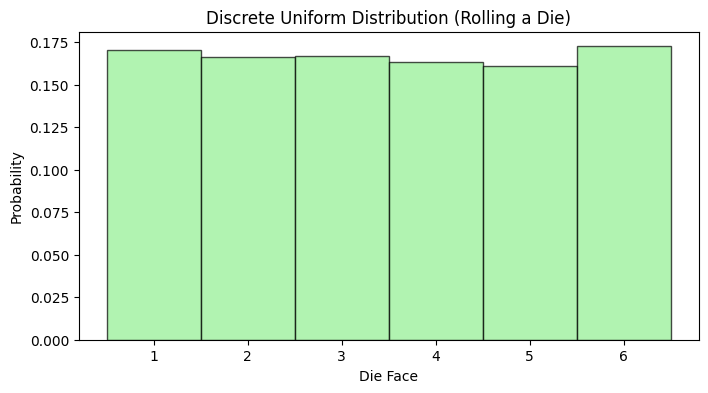

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
data_discrete = np.random.randint(low=1,high=7,size=10000)
plt.figure(figsize=(8,4))
plt.hist(data_discrete,bins=np.arange(0.5,7.5,1),density=True,alpha=0.7,color='lightgreen',edgecolor='black')
plt.title('Discrete Uniform Distribution (Rolling a Die)')
plt.xlabel('Die Face')
plt.ylabel('Probability')
plt.xticks([1,2,3,4,5,6])
plt.show()

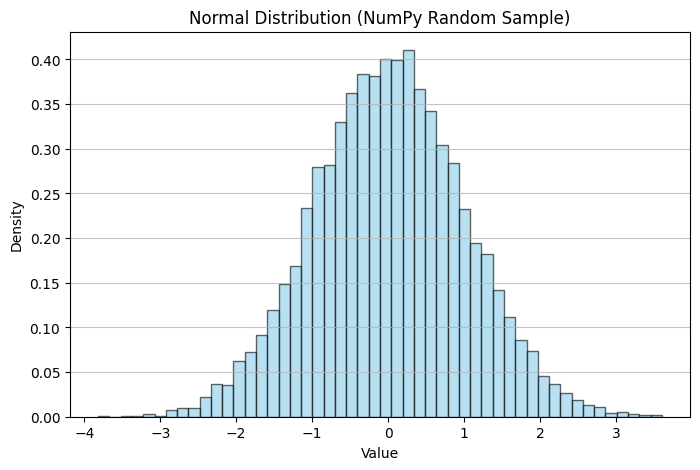

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
mu = 0
sigma = 1
sample_size = 10000
data = np.random.normal(loc=mu,scale=sigma,size=sample_size)
plt.figure(figsize=(8,5))
plt.hist(data,bins=50,density=True,alpha=0.6,color='skyblue',edgecolor='black')
plt.title('Normal Distribution (NumPy Random Sample)')
plt.xlabel('Value')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.75)
plt.show()


C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_8780\802319508.py:49: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_8780\802319508.py:49: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_8780\802319508.py:49: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_8780\802319508.py:49: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_8780\802319508.py:49: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\yuhao.bian\AppData\Local\Temp\ipykernel_8780\802319508.py:49: UserWarni

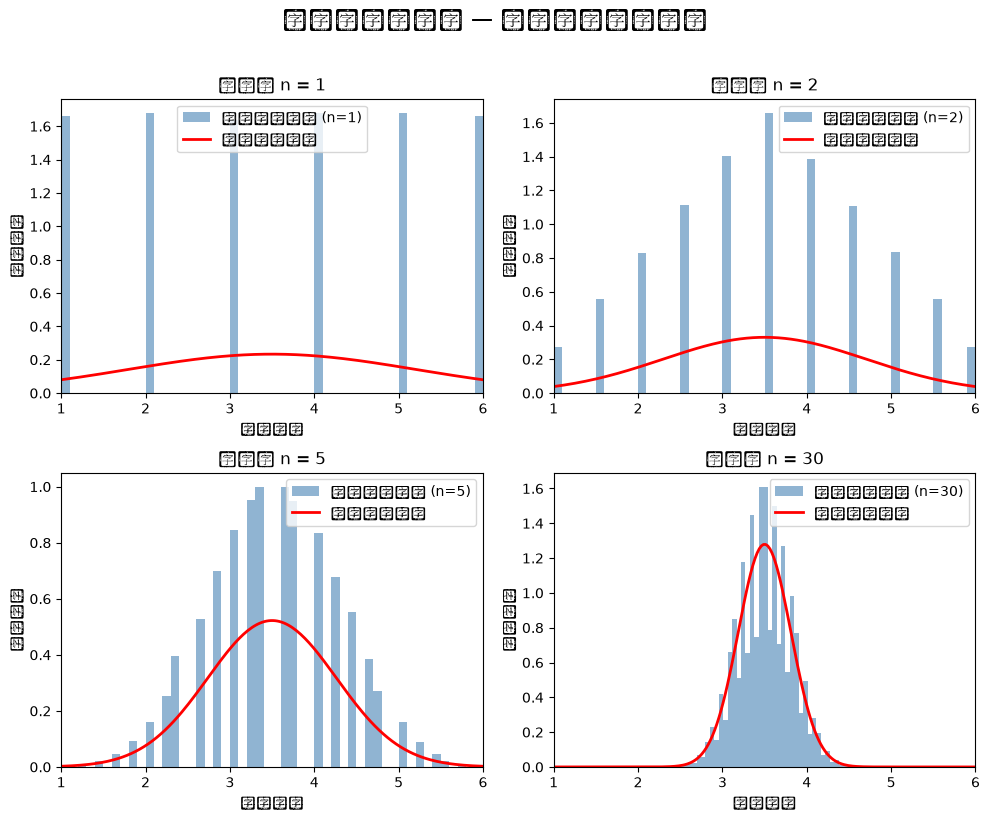

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
zh_fonts = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei', 'PingFang SC', 'Heiti SC']
for font in zh_fonts:
    try:
        matplotlib.font_manager.findfont(font, fallback_to_default=False)
        plt.rcParams['font.sans-serif'] = [font]
        break
    except:
        continue
# 解决负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False
# 设置随机种子，保证结果可复现
np.random.seed(42)

# 骰子总体的理论参数（1~6 均匀分布）
mu = 3.5                     # 总体均值
sigma = np.sqrt(35 / 12)    # 总体标准差 ≈ 1.7078

# 实验参数
N = 100000                  # 每次实验重复抽样的次数（越多直方图越平滑）
sample_sizes = [1, 2, 5, 30]  # 要展示的样本量

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, n in zip(axes, sample_sizes):
    # 模拟掷 n 个骰子，重复 N 次，每次计算平均值
    rolls = np.random.randint(1, 7, size=(N, n))
    sample_means = rolls.mean(axis=1)

    # 绘制样本均值的直方图
    ax.hist(sample_means, bins=50, density=True, alpha=0.6, color='steelblue',
            label=f'模拟均值分布 (n={n})')

    # 叠加理论正态分布曲线（中心极限定理的预测）
    x = np.linspace(1, 6, 200)
    pdf = norm.pdf(x, loc=mu, scale=sigma / np.sqrt(n))
    ax.plot(x, pdf, 'r-', lw=2, label='理论正态曲线')

    ax.set_title(f'样本量 n = {n}')
    ax.set_xlabel('样本均值')
    ax.set_ylabel('概率密度')
    ax.legend()
    ax.set_xlim(1, 6)

plt.suptitle('掷骰子均值分布 — 中心极限定理演示', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()